Train images: 1
Test images : 277

[1/4] Muestreando pixeles ROI (mask_seq) del train...
  Pixeles ROI usados: 511
  Tiempo sampling: 0.08 s

[2/4] Entrenando K-means solo en ROI...
  Compactness: 77223.68
  Tiempo kmeans: 0.01 s

Cluster | Center | Min | Max
------------------------------
0       |  86.94 |  22 | 118
1       | 149.73 | 121 | 165
2       | 180.90 | 166 | 199
3       | 218.01 | 200 | 241

[3/4] CSV guardado: C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\out_kmeans_metodo1\clusters_maskseq_K4.csv

[4/4] Aplicando centros al TEST (solo ROI mask_seq) y guardando...


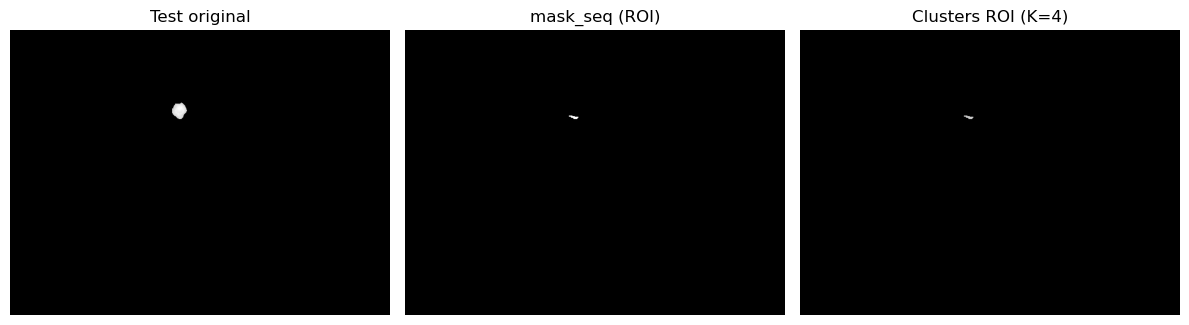

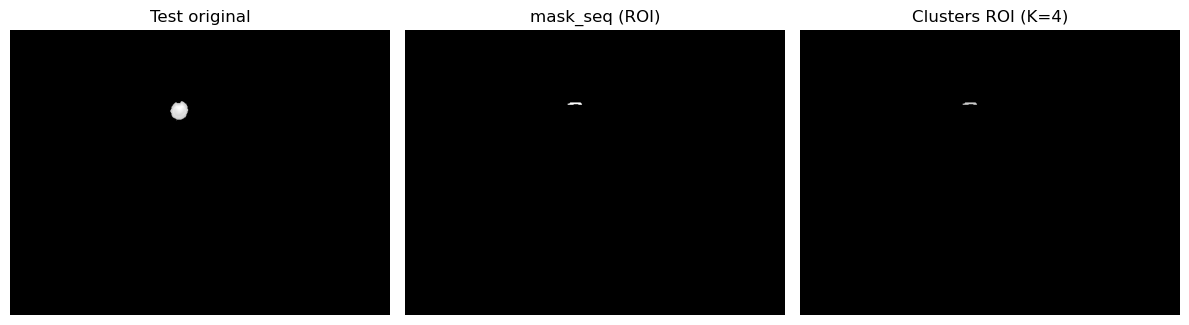

  Tiempo aplicar test: 5.55 s

✅ Terminado. Resultados en: C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\out_kmeans_metodo1
Tiempo total: 5.65 s


In [ ]:
import os
import time
import csv
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

#Ruas
TRAIN_DIR = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\Data"
TEST_DIR  = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test"
OUT_DIR   = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\out_kmeans_metodo1"

#Variables
K = 4  # 3 o 4
ROI_SCALE = 0.5          
MAX_SAMPLES = 500_000    # total de pixeles ROI para kmeans
PER_IMAGE_CAP = 8_000    # máximo pixeles ROI por imagen
SEED = 42

KMEANS_ATTEMPTS = 3
KMEANS_MAXITER = 40
KMEANS_EPS = 0.5

SHOW_EXAMPLES = 2  
os.makedirs(OUT_DIR, exist_ok=True)


def list_imgs(folder):
    return sorted(
        glob(os.path.join(folder, "*.tif")) +
        glob(os.path.join(folder, "*.tiff")) +
        glob(os.path.join(folder, "*.png")) +
        glob(os.path.join(folder, "*.jpg")) +
        glob(os.path.join(folder, "*.jpeg"))
    )

def to_uint8_gray(img):
    if img is None:
        return None
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return img

#Imagen ROI
def roi_mask_seq_method1(img_in, scale=0.5):
    img = to_uint8_gray(img_in)
    if img is None:
        return None

    H, W = img.shape
    # Downscale (acelera muchísimo distTransform + watershed)
    sW = max(64, int(W * scale))
    sH = max(64, int(H * scale))
    small = cv2.resize(img, (sW, sH), interpolation=cv2.INTER_AREA)

    blur = cv2.GaussianBlur(small, (5, 5), 0)

    # Gradiente Sobel
    sobelx = cv2.Sobel(blur, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blur, cv2.CV_32F, 0, 1, ksize=3)
    gradient = cv2.magnitude(sobelx, sobely)
    gradient = cv2.convertScaleAbs(gradient)

    # Otsu
    _, binary = cv2.threshold(gradient, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morfología (como en tu notebook)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask_morph = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    opening2 = cv2.morphologyEx(mask_morph, cv2.MORPH_OPEN, kernel, iterations=1)

    # Dist transform + sure fg
    dist_transform = cv2.distanceTransform(opening2, cv2.DIST_L2, 5)
    if dist_transform.max() == 0:
        # máscara vacía
        mask_small = np.zeros_like(opening2, dtype=np.uint8)
    else:
        _, sure_fg = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)

        # Marcadores
        _, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1

        # Watershed requiere 3 canales
        img_color = cv2.cvtColor(small, cv2.COLOR_GRAY2BGR)
        markers = cv2.watershed(img_color, markers)

        mask_small = np.zeros_like(small, dtype=np.uint8)
        mask_small[markers > 1] = 255

    # Quedarse con el componente más grande (para evitar “puntitos”)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_small, 8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        clean = np.zeros_like(mask_small)
        clean[labels == largest] = 255
        mask_small = clean

    # Upscale a tamaño original
    mask = cv2.resize(mask_small, (W, H), interpolation=cv2.INTER_NEAREST)

    # Un cierre suave final para asegurar solidez
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k2, iterations=1)

    return mask

#MUESTREO PIXELES ROI
def collect_roi_pixels_stream(train_paths, max_samples, per_image_cap, seed=42):
    rng = np.random.default_rng(seed)
    samples = []
    total = 0

    for p in train_paths:
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        m = roi_mask_seq_method1(img, ROI_SCALE)
        if m is None:
            continue

        vals = img[m > 0].astype(np.float32)
        if vals.size == 0:
            continue

        take = min(per_image_cap, vals.size, max_samples - total)
        if take <= 0:
            break

        idx = rng.choice(vals.size, size=take, replace=False)
        samples.append(vals[idx])
        total += take

        if total >= max_samples:
            break

    if total == 0:
        raise ValueError("No se obtuvieron píxeles ROI. Revisa si mask_seq está quedando vacía.")

    return np.concatenate(samples).reshape(-1, 1)

# KMEANS + center/min/max
def train_kmeans_1d(pixels, k):
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, KMEANS_MAXITER, KMEANS_EPS)
    compactness, labels, centers = cv2.kmeans(
        pixels, k, None, criteria, KMEANS_ATTEMPTS, cv2.KMEANS_PP_CENTERS
    )
    labels = labels.flatten()
    centers = centers.flatten()

    stats = []
    for i in range(k):
        v = pixels[labels == i]
        if v.size == 0:
            continue
        stats.append((i, float(centers[i]), float(v.min()), float(v.max())))
    stats.sort(key=lambda x: x[1])
    return float(compactness), centers.astype(np.float32), stats

def assign_clusters_roi(img_gray, mask, centers):
    out = np.zeros_like(img_gray, dtype=np.uint8)
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return out

    vals = img_gray[ys, xs].astype(np.float32)
    d = np.abs(vals.reshape(-1, 1) - centers.reshape(1, -1))
    lab = np.argmin(d, axis=1).astype(np.uint8)

    scale = max(1, int(255 / (len(centers) + 1)))
    out[ys, xs] = (lab + 1) * scale
    return out

#Resultado
train_paths = list_imgs(TRAIN_DIR)
test_paths  = list_imgs(TEST_DIR)

print("Train images:", len(train_paths))
print("Test images :", len(test_paths))
if not train_paths:
    raise ValueError("TRAIN_DIR no tiene imágenes.")
if not test_paths:
    raise ValueError("TEST_DIR no tiene imágenes.")

t0 = time.time()
print("\n[1/4] Muestreando pixeles ROI (mask_seq) del train...")
pixels = collect_roi_pixels_stream(train_paths, MAX_SAMPLES, PER_IMAGE_CAP, SEED)
print("  Pixeles ROI usados:", pixels.shape[0])
print("  Tiempo sampling:", round(time.time() - t0, 2), "s")

t1 = time.time()
print("\n[2/4] Entrenando K-means solo en ROI...")
compactness, centers, stats = train_kmeans_1d(pixels, K)
print("  Compactness:", round(compactness, 2))
print("  Tiempo kmeans:", round(time.time() - t1, 2), "s")

# Mostrar tabla como tu ejemplo
print("\nCluster | Center | Min | Max")
print("-" * 30)
for cid, c, mn, mx in stats:
    print(f"{cid:<7} | {c:>6.2f} | {mn:>3.0f} | {mx:>3.0f}")

# Exportar CSV
csv_path = os.path.join(OUT_DIR, f"clusters_maskseq_K{K}.csv")
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["cluster_id", "center", "min", "max"])
    for cid, c, mn, mx in stats:
        w.writerow([cid, round(c, 3), round(mn, 3), round(mx, 3)])
print("\n[3/4] CSV guardado:", csv_path)

t2 = time.time()
print("\n[4/4] Aplicando centros al TEST (solo ROI mask_seq) y guardando...")
shown = 0
for p in test_paths:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue

    mask = roi_mask_seq_method1(img, ROI_SCALE)
    roi_only = cv2.bitwise_and(img, img, mask=mask)
    clusters_map = assign_clusters_roi(img, mask, centers)

    base = os.path.splitext(os.path.basename(p))[0]
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_roi.png"), roi_only)
    cv2.imwrite(os.path.join(OUT_DIR, f"{base}_clusters_K{K}.png"), clusters_map)

    if shown < SHOW_EXAMPLES:
        shown += 1
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1); plt.imshow(img, cmap="gray"); plt.title("Test original"); plt.axis("off")
        plt.subplot(1, 3, 2); plt.imshow(mask, cmap="gray"); plt.title("mask_seq (ROI)"); plt.axis("off")
        plt.subplot(1, 3, 3); plt.imshow(clusters_map, cmap="nipy_spectral"); plt.title(f"Clusters ROI (K={K})"); plt.axis("off")
        plt.tight_layout()
        plt.show()

print("  Tiempo aplicar test:", round(time.time() - t2, 2), "s")
print("\n✅ Terminado. Resultados en:", OUT_DIR)
print("Tiempo total:", round(time.time() - t0, 2), "s")